# GO:BP GPU Hypergeometric ORA Saturation Plot (study subsampling)

**Environment:** `clamp-analyses`

Reads per-model CSV caches produced by `00_bp_gpu_ora_analysis.ipynb` (full K grid, dynamically
discovered, plus the shared 100% anchor). Plots GO:BP pathway coverage (FDR < 0.05 / FDR < 0.01)
against K. Mirrors `gpu_ora_msigdb`'s saturation plot notebook structure. No PDF export.

In [1]:
library(here)
library(ggplot2)
library(dplyr)

input_dir <- here("output/03_model_biology/00_archs4/08_saturation_study/gpu_ora_bp")

theme_ng <- function() {
  theme_classic(base_size = 18) +
    theme(
      axis.title        = element_text(size = 24, colour = "black"),
      axis.title.y      = element_text(margin = margin(r = 18)),
      axis.text         = element_text(size = 18, colour = "black"),
      axis.line         = element_line(linewidth = 0.8, colour = "black"),
      axis.ticks        = element_line(linewidth = 0.8, colour = "black"),
      axis.ticks.length = unit(0.22, "cm"),
      panel.grid.major.y = element_line(colour = "#BDBDBD", linewidth = 0.7),
      panel.grid.minor   = element_blank(),
      legend.position    = "right",
      strip.background   = element_blank(),
      strip.text         = element_text(face = "bold", size = 18),
      plot.margin        = margin(t = 16, r = 12, b = 12, l = 42)
    )
}

here() starts at /home/msubirana/Documents/pivlab/clamp-analyses


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## Load results: full discovered grid

In [2]:
load_model_results <- function(model_type) {
  term_files <- list.files(
    file.path(input_dir, model_type),
    pattern    = "^rs[0-9]+_k[0-9]+_seed[0-9]+_bp_gpu_ora\\.csv$",
    full.names = TRUE
  )
  if (length(term_files) == 0) {
    warning(sprintf("No grid CSVs found for %s", model_type))
    return(NULL)
  }

  rows <- lapply(term_files, function(f) {
    m <- regmatches(basename(f), regexec("^rs([0-9]+)_k([0-9]+)_seed([0-9]+)_bp_gpu_ora\\.csv$", basename(f)))[[1]]
    if (length(m) < 4) return(NULL)
    meta_path <- sub("_bp_gpu_ora\\.csv$", "_meta.csv", f)
    if (!file.exists(meta_path)) return(NULL)
    meta  <- read.csv(meta_path, check.names = FALSE)
    terms <- read.csv(f, check.names = FALSE)
    if (nrow(terms) == 0) return(NULL)
    data.frame(
      rs_pct           = as.integer(m[2]),
      k_val            = as.integer(m[3]),
      seed             = as.integer(m[4]),
      n_samples        = meta$n_samples[1],
      n_total_bp       = meta$n_total_msigdb[1],
      coverage_fdr05   = sum(terms$padj_min_across_lvs < 0.05) / meta$n_total_msigdb[1],
      coverage_fdr01   = sum(terms$padj_min_across_lvs < 0.01) / meta$n_total_msigdb[1],
      stringsAsFactors = FALSE
    )
  })
  grid_df <- do.call(rbind, Filter(Negate(is.null), rows))
  if (is.null(grid_df)) return(NULL)

  grid_df <- grid_df %>%
    dplyr::group_by(rs_pct, k_val) %>%
    dplyr::summarise(
      n_samples      = median(n_samples, na.rm = TRUE),
      n_total_bp     = median(n_total_bp, na.rm = TRUE),
      coverage_fdr05 = mean(coverage_fdr05, na.rm = TRUE),
      coverage_fdr01 = mean(coverage_fdr01, na.rm = TRUE),
      .groups = "drop"
    )

  grid_df[order(grid_df$rs_pct, grid_df$k_val), ]
}

results_full <- load_model_results("CLAMPfull")
results_base <- load_model_results("CLAMPbase")

message("CLAMPfull rows: ", if (!is.null(results_full)) nrow(results_full) else 0)
message("CLAMPbase rows: ", if (!is.null(results_base)) nrow(results_base) else 0)

CLAMPfull rows: 27

CLAMPbase rows: 27



## Prepare plot data

In [3]:
coverage_colors <- c(
  "1%"   = "#2166AC",
  "5%"   = "#4DAC26",
  "10%"  = "#D6604D",
  "25%"  = "#762A83",
  "50%"  = "#E08214",
  "75%"  = "#1B9E77",
  "100%" = "#000000"
)
coverage_shapes <- c("1%"=16, "5%"=3, "10%"=1, "25%"=17, "50%"=15, "75%"=8, "100%"=18)

make_plot_df <- function(df) {
  if (is.null(df)) return(NULL)
  # rs_pct levels are discovered dynamically (not all of 1/5/10/25/50/75/100 necessarily
  # have data for a given model type) -- build the factor from whatever is present, in the
  # canonical pct order, rather than hardcoding which levels exist (avoids NA categories
  # for e.g. rs_pct=50 models that exist on disk for the study-subsampling saturation grid).
  present_pcts <- sort(unique(df$rs_pct))
  canonical_order <- c(1, 5, 10, 25, 50, 75, 100)
  level_order <- paste0(canonical_order[canonical_order %in% present_pcts], "%")
  df %>%
    dplyr::mutate(
      data_label         = factor(paste0(rs_pct, "%"), levels = level_order),
      coverage_fdr05_pct = coverage_fdr05 * 100,
      coverage_fdr01_pct = coverage_fdr01 * 100
    )
}

plot_full <- make_plot_df(results_full)
plot_base <- make_plot_df(results_base)

## Plot helper

In [4]:
make_sat_plot <- function(plot_df, y_col, y_label) {
  if (is.null(plot_df)) { message("No data, skipping plot"); return(invisible(NULL)) }
  ggplot(plot_df, aes(x = k_val, y = .data[[y_col]], colour = data_label)) +
    geom_line(aes(group = data_label), linewidth = 1.0) +
    geom_point(aes(shape = data_label), size = 3.0, stroke = 1.0) +
    scale_colour_manual(values = coverage_colors, name = "ARCHS4") +
    scale_shape_manual(values  = coverage_shapes, name = "ARCHS4") +
    scale_y_continuous(
      labels = scales::percent_format(accuracy = 0.1, scale = 1),
      breaks = scales::breaks_width(2.5),
      expand = expansion(mult = c(0.08, 0.08))
    ) +
    labs(x = "K (number of LVs)", y = y_label) +
    theme_ng()
}

options(repr.plot.width = 10, repr.plot.height = 7)

## CLAMPfull: FDR 0.05

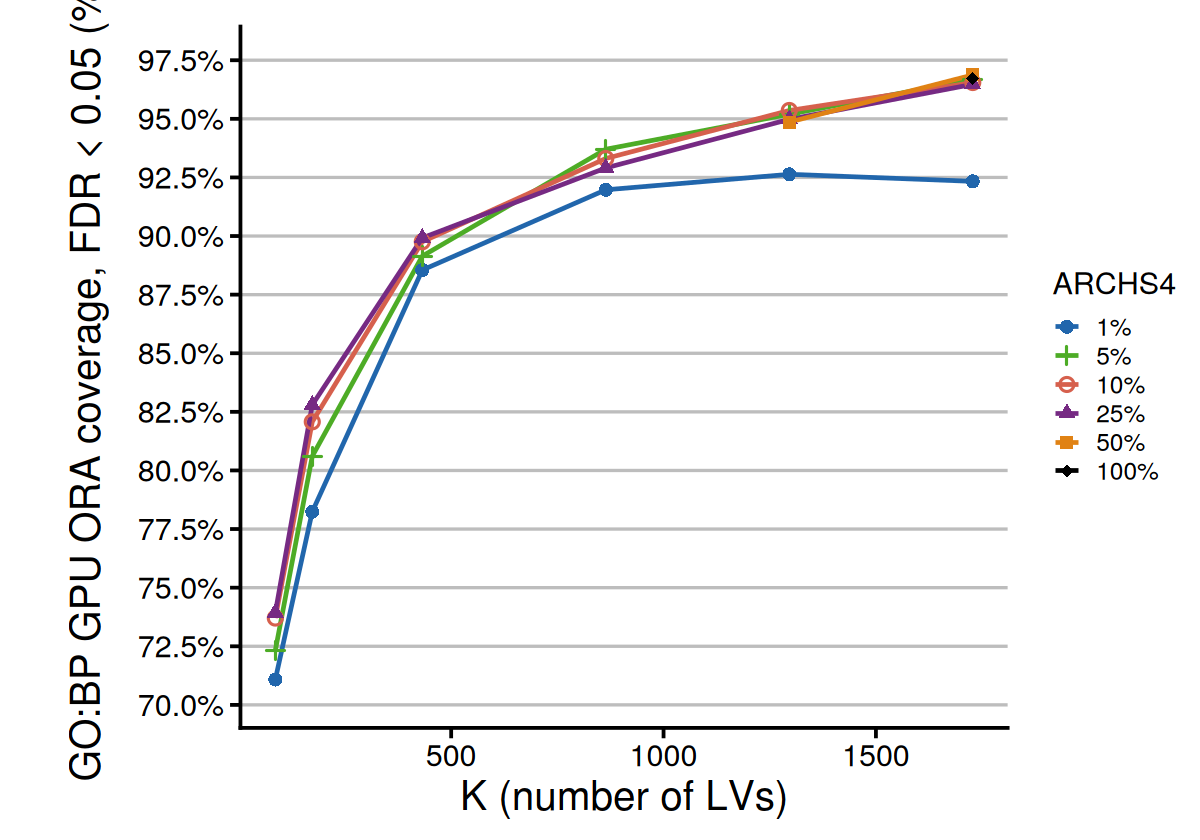

In [5]:
p_full_05 <- make_sat_plot(plot_full, "coverage_fdr05_pct", "GO:BP GPU ORA coverage, FDR < 0.05 (%)")
p_full_05

## CLAMPfull: FDR 0.01

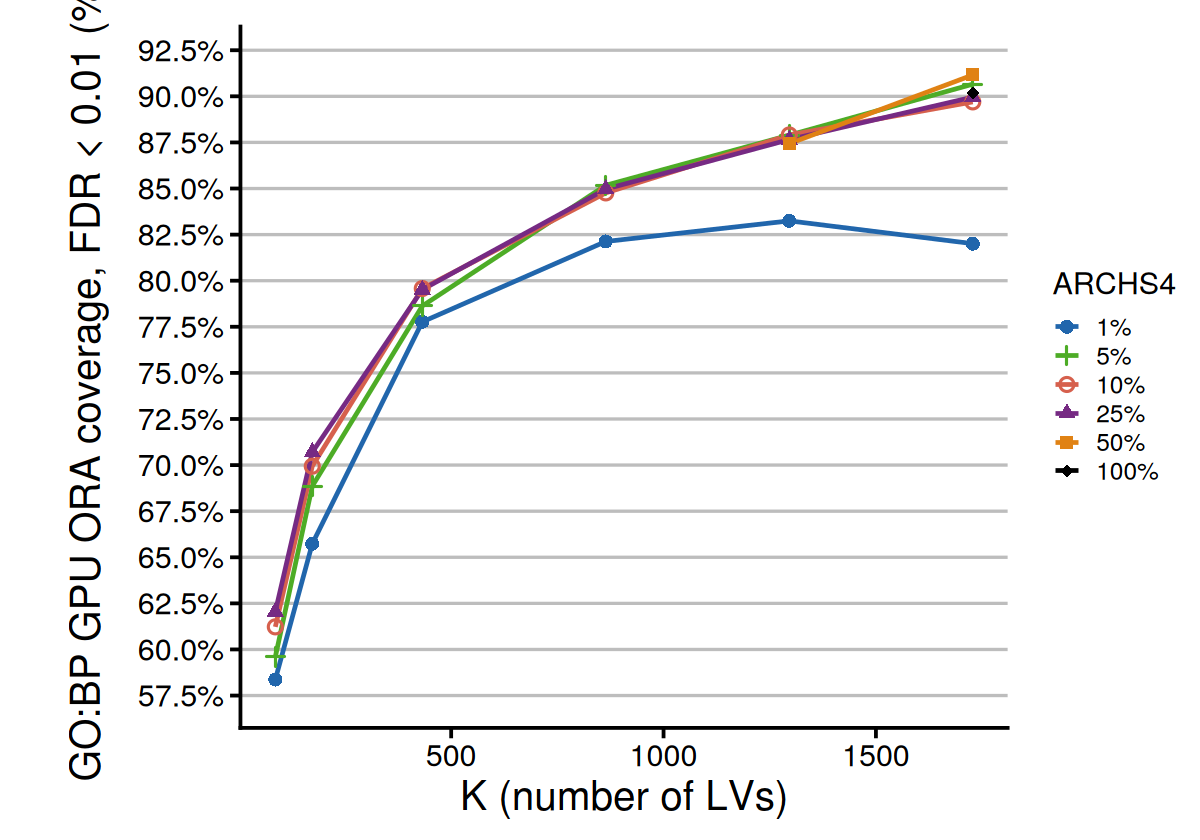

In [6]:
p_full_01 <- make_sat_plot(plot_full, "coverage_fdr01_pct", "GO:BP GPU ORA coverage, FDR < 0.01 (%)")
p_full_01

## CLAMPbase: FDR 0.05

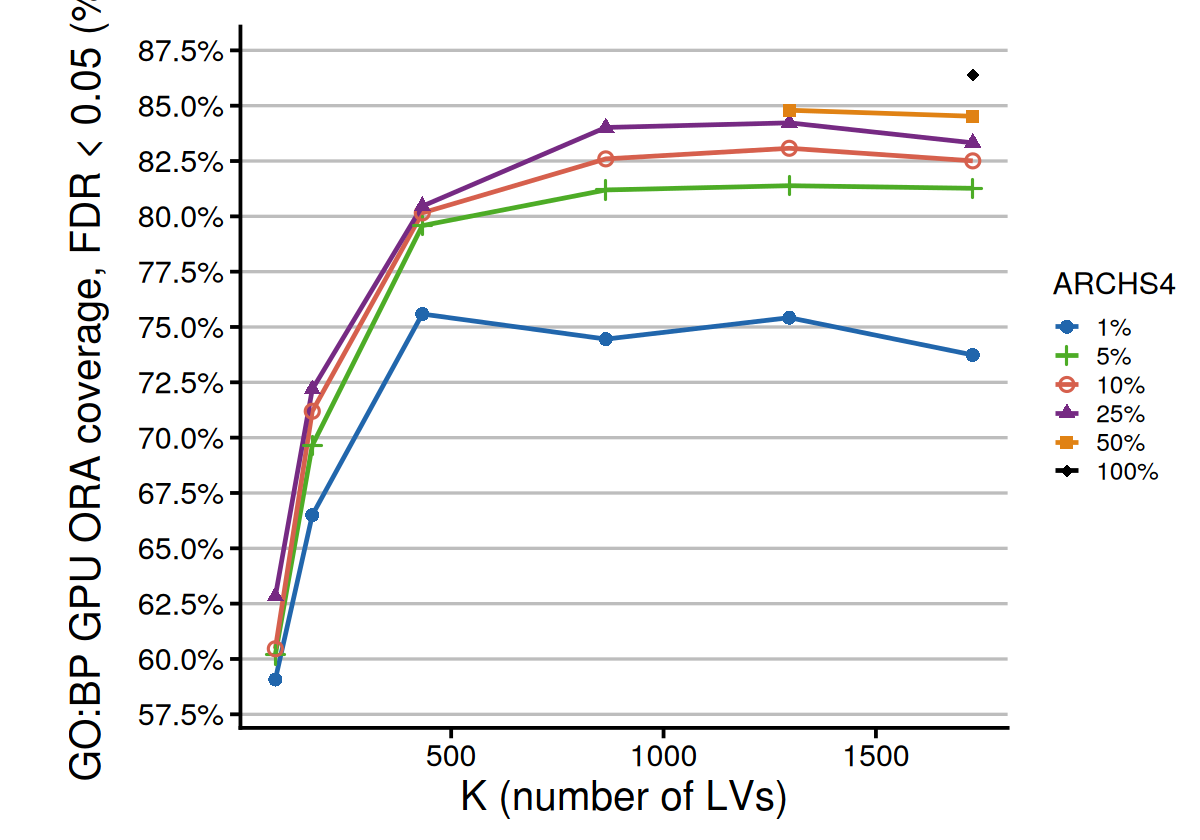

In [7]:
p_base_05 <- make_sat_plot(plot_base, "coverage_fdr05_pct", "GO:BP GPU ORA coverage, FDR < 0.05 (%)")
p_base_05

## CLAMPbase: FDR 0.01

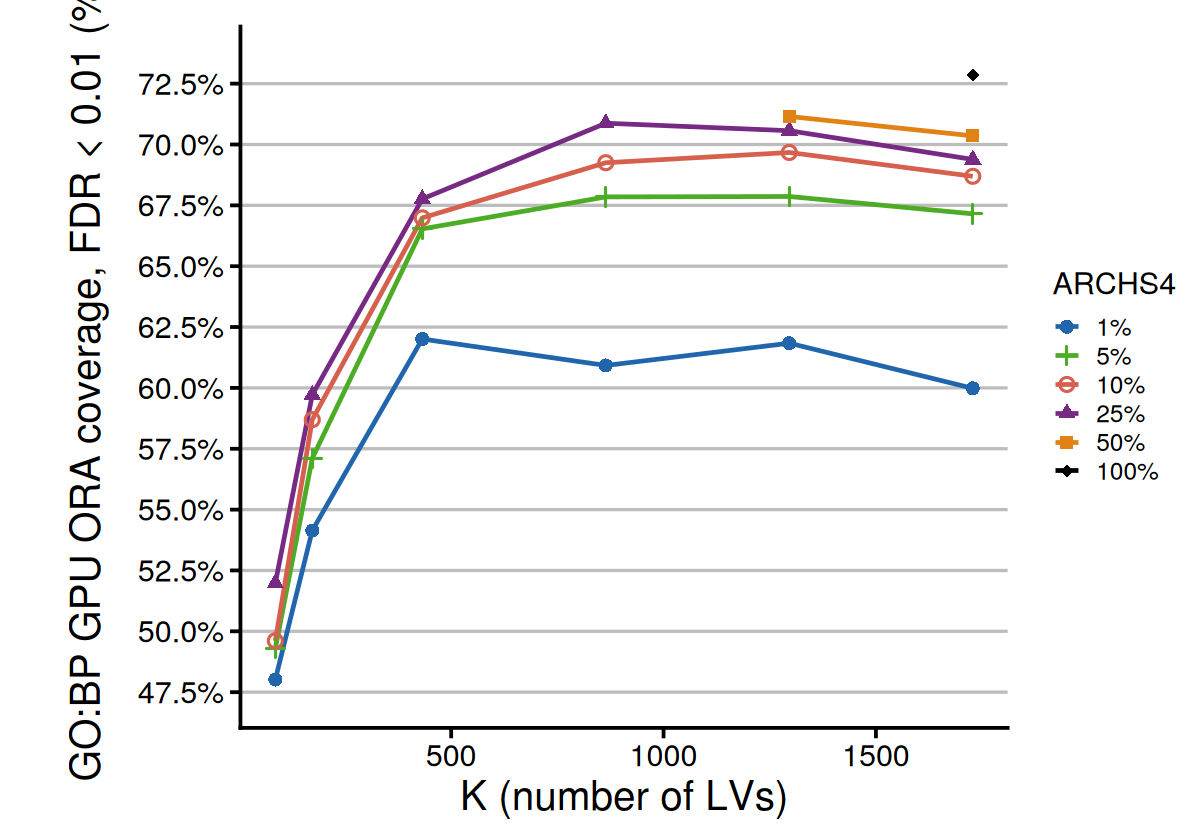

In [8]:
p_base_01 <- make_sat_plot(plot_base, "coverage_fdr01_pct", "GO:BP GPU ORA coverage, FDR < 0.01 (%)")
p_base_01